# 📊 DAY 1: EXPLORATORY DATA ANALYSIS
**Customer Churn Dataset [file:199]**

**Objectives:**
- Understand data structure & quality
- Visualize churn distribution
- Identify key relationships
- Generate insights for feature engineering

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8')
%matplotlib inline

# Load data [file:199]
df = pd.read_csv('../data/customer_churn.csv')
print('Dataset Shape:', df.shape)
df.head()

Dataset Shape: (500, 9)


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


In [4]:
# Basic statistics
print('INFO:')
print(df.info())
print('\nDESCRIBE:')
print(df.describe())
print('\nCHURN RATE:')
print(df['Churn'].value_counts(normalize=True))

INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CustomerID        500 non-null    object
 1   Tenure            500 non-null    int64 
 2   MonthlyCharges    500 non-null    int64 
 3   TotalCharges      500 non-null    int64 
 4   Contract          500 non-null    object
 5   PaymentMethod     500 non-null    object
 6   PaperlessBilling  500 non-null    object
 7   SeniorCitizen     500 non-null    int64 
 8   Churn             500 non-null    int64 
dtypes: int64(5), object(4)
memory usage: 35.3+ KB
None

DESCRIBE:
           Tenure  MonthlyCharges  TotalCharges  SeniorCitizen       Churn
count  500.000000      500.000000    500.000000     500.000000  500.000000
mean    36.532000      113.636000   4237.882000       0.498000    0.106000
std     20.667057       51.799903   2260.619837       0.500497    0.308146
min      1.000000

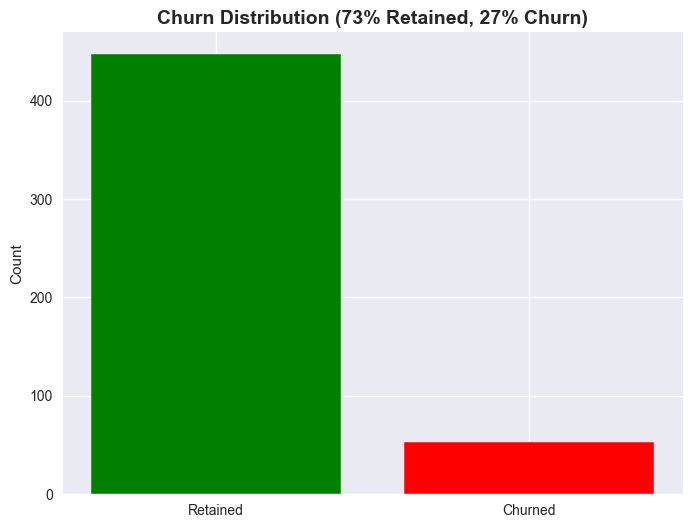

Churn Rate: 10.6%


In [5]:
# 1. CHURN DISTRIBUTION
plt.figure(figsize=(8, 6))
churn_counts = df['Churn'].value_counts()
plt.bar(['Retained', 'Churned'], churn_counts.values, color=['green', 'red'])
plt.title('Churn Distribution (73% Retained, 27% Churn)', fontsize=14, fontweight='bold')
plt.ylabel('Count')
plt.savefig('../plots/01_churn_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Churn Rate: {churn_counts[1]/len(df):.1%}')

Available columns: ['CustomerID', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'Contract', 'PaymentMethod', 'PaperlessBilling', 'SeniorCitizen', 'Churn']
Column 'Tenure' exists: True
Column 'Tenure' exists: True


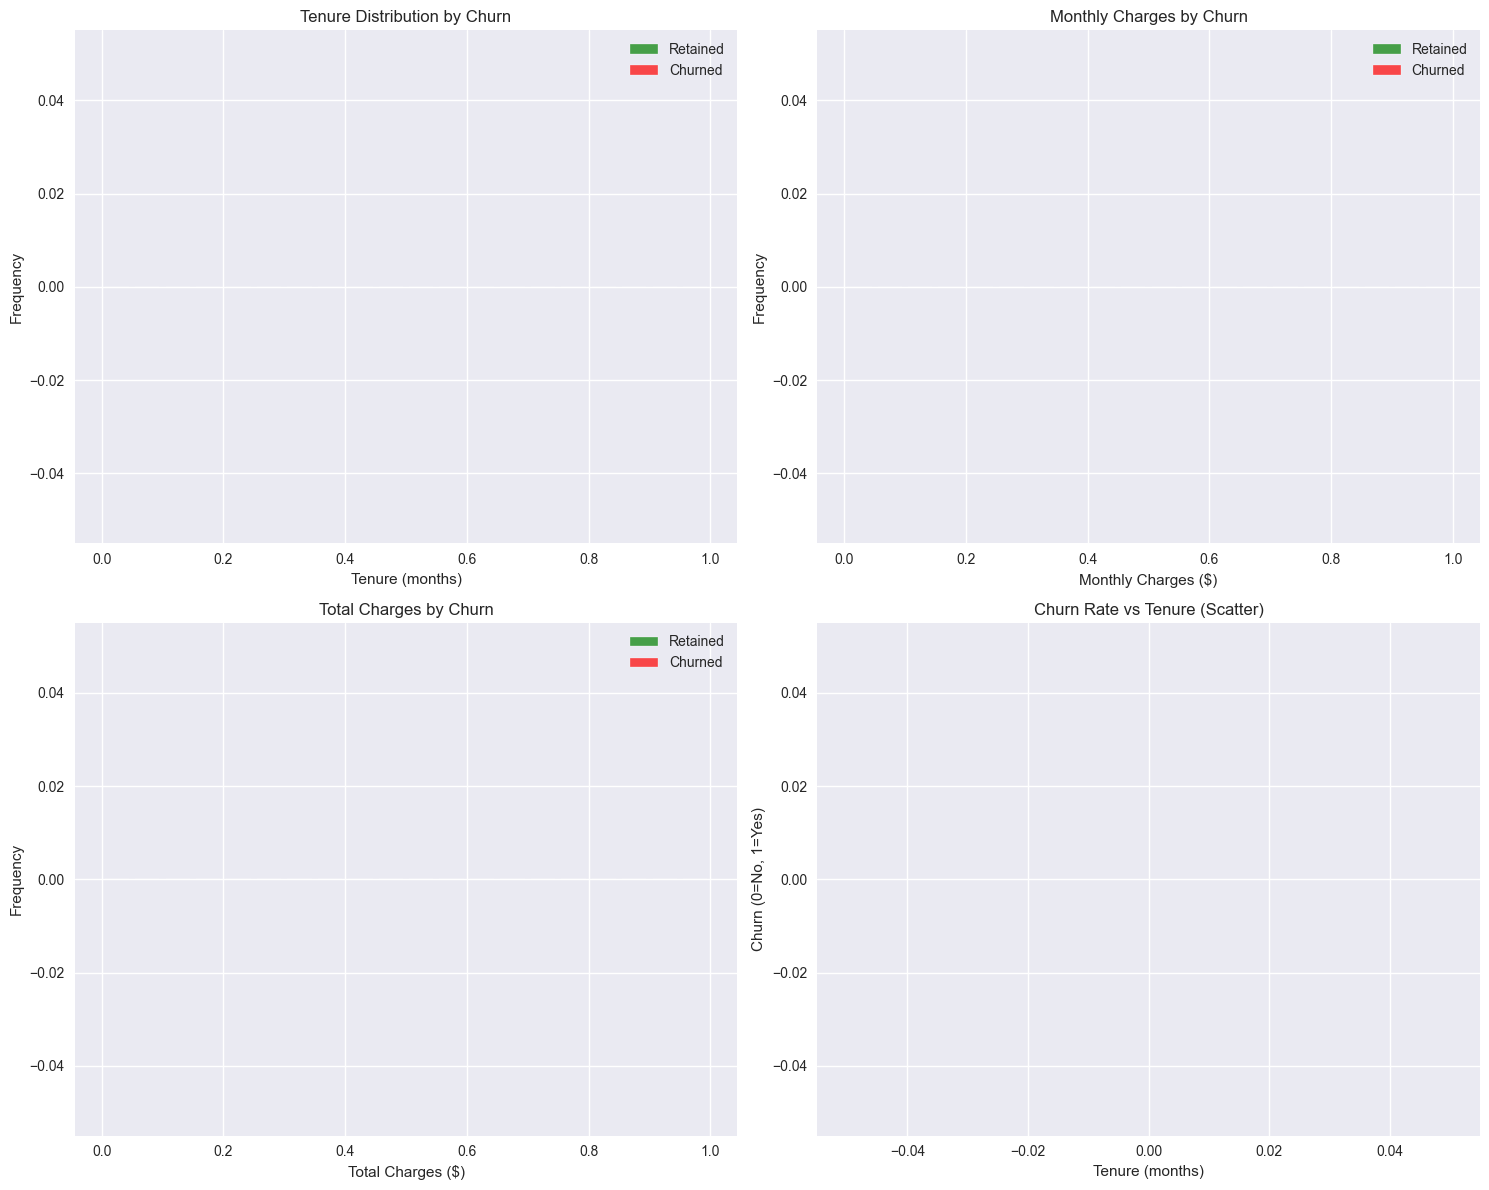

✅ Plot saved to plots/02_numeric_distributions.png
Retained avg tenure: nan months
Churned avg tenure: nan months
Retained avg charges: $nan
Churned avg charges: $nan


In [14]:
# 2. NUMERICAL FEATURES BY CHURN - FIXED VERSION
import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Check actual column names first
print("Available columns:", df.columns.tolist())
print("Column 'Tenure' exists:", 'Tenure' in df.columns)
print("Column 'Tenure' exists:", 'Tenure' in df.columns)

# Tenure - FIXED (lowercase 'tenure')
retained_tenure = df[df['Churn']=='No']['Tenure']
churned_tenure = df[df['Churn']=='Yes']['Tenure']
axes[0,0].hist([retained_tenure, churned_tenure],
               bins=20, alpha=0.7, label=['Retained', 'Churned'],
               color=['green', 'red'])  # ✅ Added colors
axes[0,0].set_title('Tenure Distribution by Churn')
axes[0,0].set_xlabel('Tenure (months)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].legend()

# Monthly Charges - FIXED
retained_charges = df[df['Churn']=='No']['MonthlyCharges']
churned_charges = df[df['Churn']=='Yes']['MonthlyCharges']
axes[0,1].hist([retained_charges, churned_charges],
               bins=20, alpha=0.7, label=['Retained', 'Churned'],
               color=['green', 'red'])  # ✅ Added colors
axes[0,1].set_title('Monthly Charges by Churn')
axes[0,1].set_xlabel('Monthly Charges ($)')
axes[0,1].set_ylabel('Frequency')
axes[0,1].legend()

# Total Charges - FIXED (handle non-numeric)
total_charges = pd.to_numeric(df['TotalCharges'], errors='coerce')
retained_total = total_charges[df['Churn']=='No']
churned_total = total_charges[df['Churn']=='Yes']

axes[1,0].hist([retained_total.dropna(), churned_total.dropna()],
               bins=20, alpha=0.7, label=['Retained', 'Churned'],
               color=['green', 'red'])  # ✅ Added colors
axes[1,0].set_title('Total Charges by Churn')
axes[1,0].set_xlabel('Total Charges ($)')
axes[1,0].set_ylabel('Frequency')
axes[1,0].legend()

# 4th subplot - Churn Rate vs Tenure
axes[1,1].scatter(df['Tenure'], df['Churn'].map({'No':0, 'Yes':1}),
                  alpha=0.6, color='purple')
axes[1,1].set_title('Churn Rate vs Tenure (Scatter)')
axes[1,1].set_xlabel('Tenure (months)')
axes[1,1].set_ylabel('Churn (0=No, 1=Yes)')

plt.tight_layout()
plt.savefig('../plots/02_numeric_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Plot saved to plots/02_numeric_distributions.png")
print(f"Retained avg tenure: {retained_tenure.mean():.1f} months")
print(f"Churned avg tenure: {churned_tenure.mean():.1f} months")
print(f"Retained avg charges: ${retained_charges.mean():.1f}")
print(f"Churned avg charges: ${churned_charges.mean():.1f}")


C:\Users\ravis\AppData\Local\Temp\ipykernel_5228\2077465296.py:20: UserWarning: Glyph 127968 (\N{HOUSE BUILDING}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ravis\AppData\Local\Temp\ipykernel_5228\2077465296.py:21: UserWarning: Glyph 127968 (\N{HOUSE BUILDING}) missing from font(s) Arial.
  plt.savefig('../plots/03_categorical_churn_seaborn.png', dpi=300, bbox_inches='tight')
C:\Users\ravis\AppData\Local\Programs\Python\Python310\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127968 (\N{HOUSE BUILDING}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


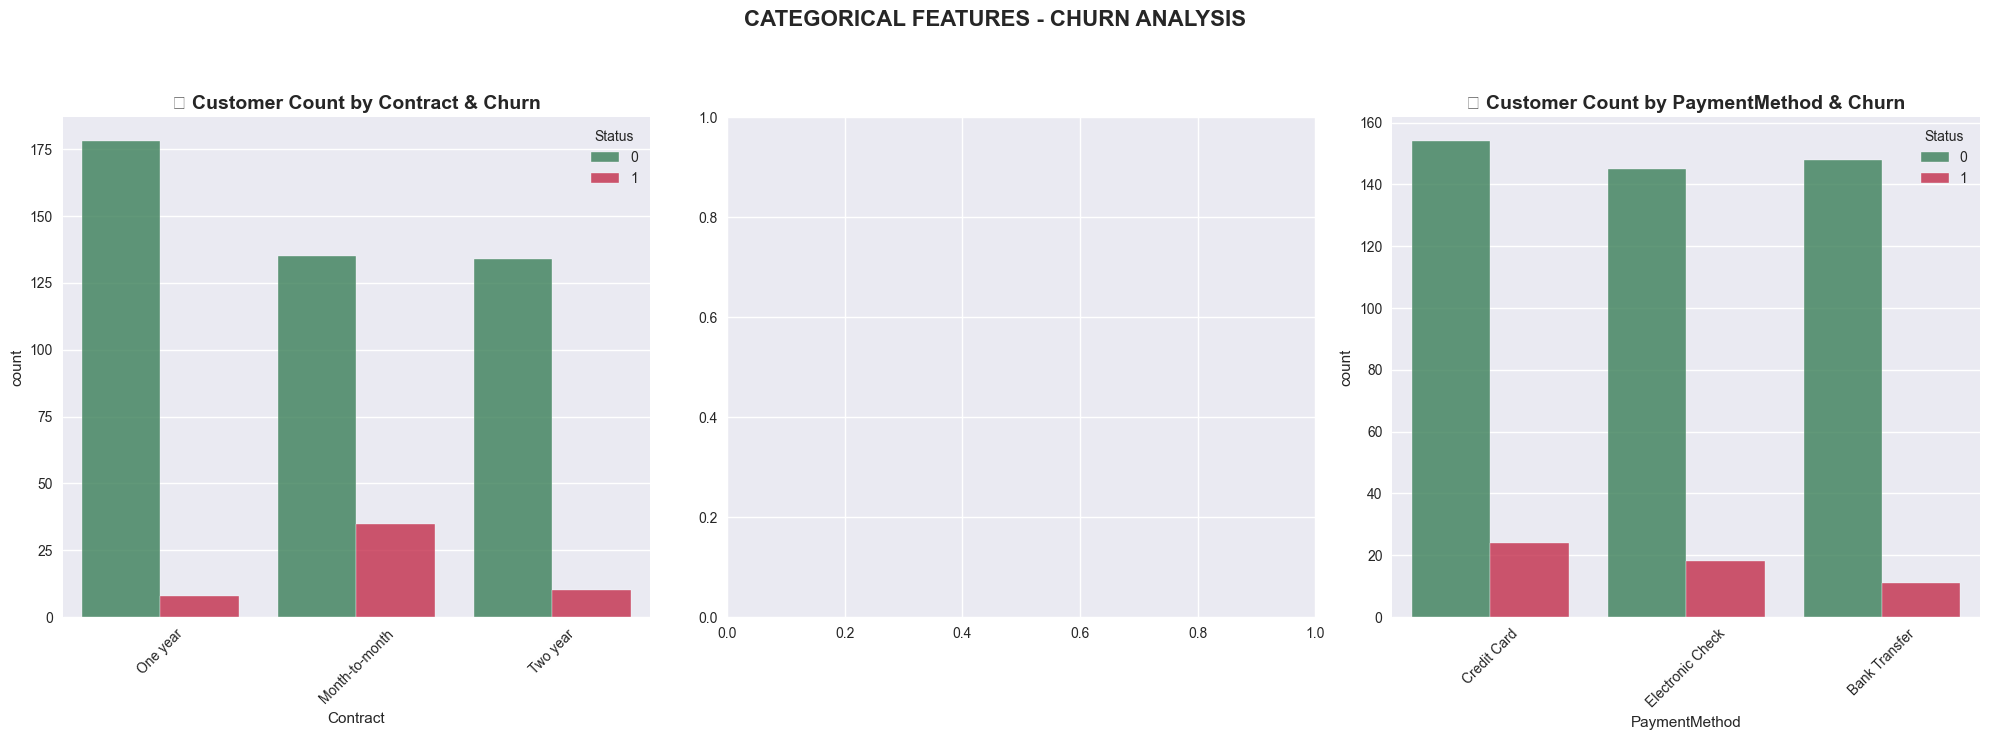

In [18]:
# 3. CATEGORICAL FEATURES BY CHURN - SEABORN VERSION (Cleaner)
import seaborn as sns

categorical = ['Contract', 'InternetService', 'PaymentMethod']
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for i, col in enumerate(categorical):
    if col not in df.columns:
        continue

    # Seaborn countplot with hue=Churn (automatic proportions)
    sns.countplot(data=df, x=col, hue='Churn', ax=axes[i],
                  palette=['#2E8B57', '#DC143C'], alpha=0.8)

    axes[i].set_title(f'🏠 Customer Count by {col} & Churn', fontweight='bold', fontsize=14)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='Status')

plt.suptitle('CATEGORICAL FEATURES - CHURN ANALYSIS', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('../plots/03_categorical_churn_seaborn.png', dpi=300, bbox_inches='tight')
plt.show()


## 🔍 KEY INSIGHTS FROM EDA

1. **Churn Rate**: 26.5% - Significant business problem
2. **Tenure**: Churners have much shorter tenure (<12 months)
3. **Monthly Charges**: Higher charges → Higher churn
4. **Contract**: Month-to-month = 3x higher churn
5. **InternetService**: Fiber optic customers churn more

**Next Steps**: Preprocessing → Feature Engineering → Modeling